In [1]:

#n:\Projects\11211000\11211479\C. Report - advise\004\Decision Support System locks\OpenTNSim_python_files\Terneuzen\
# package(s) used for creating and geo-locating the graph
# package(s) used for creating and geo-locating the graph
import networkx as nx
import pyproj
from shapely.geometry import Point, LineString, Polygon
from shapely.ops import transform

# package(s) related to the simulation (creating the vessel, running the simulation)
import datetime
import simpy
import opentnsim
from opentnsim.graph import mixins as graph_module
from opentnsim.core.logutils import logbook2eventtable
from opentnsim.core import Identifiable, Movable, VesselProperties, ExtraMetadata
from opentnsim.core.visualizations import generate_vessel_gantt_chart
from opentnsim.graph.mixins import HasMultiDiGraph
from opentnsim.output import HasOutput
from scipy.stats import norm, uniform, expon
import folium

# import of modules important for locking
from opentnsim.lock import IsLockChamber, IsLockWaitingArea, IsLockComplex, LockComplexTraversable
import geopandas as gpd
import opentnsim.core.utils as core_utils
from opentnsim import fis
# package(s) needed for inspecting the output
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# river_WL_geojson_path = r'''n:\Projects\11211000\11211479\C. Report - advise\004\OpenTNSim_Terneuzen\Lock_geometrie_files\river_waterlevel.geojson'''
# river_VELO_geojson_path = r'''n:\Projects\11211000\11211479\C. Report - advise\004\OpenTNSim_Terneuzen\Lock_geometrie_files\river_velocity.geojson'''
print("This notebook is executed with OpenTNSim version {}".format(opentnsim.__version__))

This notebook is executed with OpenTNSim version 1.3.4


In [2]:
def find_closest_edge_to_point(graph, point):
    distance_to_edge = {}
    point_transformed = point #flip_coordinates(point) 
    for edge in graph.edges(data = True):
        edge_name = (edge[0],edge[1])
        edge_info = edge[2]
        edge_geometry = edge_info["geometry"]
        distance_to_edge[edge_name] = point_transformed.distance(edge_geometry)
    
    closest_edge = list(distance_to_edge.keys())[np.argmin(list(distance_to_edge.values()))]
    return closest_edge

def get_closest_node_to_point(graph, point):
    closest_edge = find_closest_edge_to_point(graph, point)
    distance_to_node = {}
    point_transformed = point #flip_coordinates(point) 
    for node in closest_edge:
        node_geometry = graph.nodes[node]["geometry"]
        distance_to_node[node] = point_transformed.distance(node_geometry)
    
    closest_node = list(distance_to_node.keys())[np.argmin(list(distance_to_node.values()))]
    return closest_node

def get_closest_location_on_edge_to_point(FG,edge,point):
    edge_geometry = FG.edges[edge]["geometry"]
    point_on_edge = edge_geometry.interpolate(edge_geometry.project(point))
    return point_on_edge

def calculate_distance_along_geometry_to_nodes_of_edge(graph, edge, point):
    
    edge_geometry = graph.edges[edge]["geometry"]
    return distance_to_start_node, distance_to_end_node

def find_nodes_in_a_polygon(graph ,lock_polygon):
    nodes = []
    for node in graph.nodes(data = True):
        node_info = node[1]
        node_geometry = node_info["geometry"]
        if lock_polygon.intersects(node_geometry):
            nodes.append(node[0])
    return nodes

def find_edges_in_a_polygon(lock_polygon):
    edges = []
    for edge in FG.edges(data = True): #aangepast
        start_node = edge[0]
        end_node = edge[1]
        edge_info = edge[2]
        edge_geometry = edge_info["geometry"]
        if lock_polygon.intersects(edge_geometry):
            edges.append((start_node,end_node))
    return edges

def calculate_length_of_splitted_edge_geometries(graph, edge, edge_geometries):
    edge_geometry_lengths = [edge_geometry.length for edge_geometry in edge_geometries]
    sum_edge_length = np.sum(edge_geometry_lengths)
    fractive_edge_parts_lengths = edge_geometry_lengths/sum_edge_length
    edge_parts_lenghts_m = fractive_edge_parts_lengths*graph.edges[edge]["length_m"]  
    return edge_parts_lenghts_m

def find_edges_based_on_shared_node(graph, node):
    edges = []
    for edge in graph.edges:
        if node in edge:
            edges.append(edge)
    return edges

def compare_two_edge_info(graph ,edge_A,edge_B):
    edge_info_A = graph.edges[edge_A]
    edge_info_B = graph.edges[edge_B]
    shared_items = {k: edge_info_A[k] for k in edge_info_A if k in edge_info_B and str(edge_info_A[k]) == str(edge_info_B[k])}
    missing_items_A = edge_info_A.keys() - shared_items.keys()
    missing_items_B = edge_info_B.keys() - shared_items.keys()
    return shared_items, missing_items_A, missing_items_B

import pyproj
from shapely.ops import transform

def transform_geometry(geometry, epsg_in = "EPSG:4326", epsg_out = "EPSG:8857"):
    #EPSG:8857 is equal earth projection
    crs_in = pyproj.CRS(epsg_in)
    crs_out = pyproj.CRS(epsg_out)
    crs_in_to_crs_out = pyproj.transformer.Transformer.from_crs(crs_in, crs_out, always_xy=True).transform
    geometry_transformed = transform(crs_in_to_crs_out,geometry)
    return geometry_transformed

def remove_node_from_network(graph, node):
    graph.remove_node(node)
    return    

import warnings
from shapely.ops import linemerge
def merge_two_consecutive_edges_based_on_shared_node(graph, node):
    if node not in graph.nodes:
        warnings.warn(f"Node ({node}) does not exist in graph, merging aborted.")
        return
    
    edges = find_edges_based_on_shared_node(graph, node)
    number_of_edges = len(edges)
    if number_of_edges != 2:
        if number_of_edges > 2:
            warnings.warn(f"Node ({node}) has multiple ({number_of_edges}) edges, merging aborted.")
        else:
            warnings.warn(f"Node ({node}) has only one edge, merging aborted.")
        return

    edge_A, edge_B = edges
    start_junction_id = list(set(edge_A)-set(edge_B))[0]
    end_junction_id = list(set(edge_B)-set(edge_A))[0]

    edge_info_A = graph.edges[edge_A]
    edge_info_B = graph.edges[edge_B]
    edge_geometry_A = graph.edges[edge_A]["geometry"]
    edge_geometry_B = graph.edges[edge_B]["geometry"]
    new_edge_geometry = linemerge([edge_geometry_A,edge_geometry_B])
    
    shared_items, missing_items_A, missing_items_B = compare_two_edge_info(graph, edge_A,edge_B)
    #new_edge_data = shared_items
    
    #from chat 
    new_edge_data = shared_items.copy()

    # Preserve Name explicitly
    name_A = edge_info_A.get("Name")
    name_B = edge_info_B.get("Name")

    if name_A == name_B:
        new_edge_data["Name"] = name_A
    elif name_A and name_B:
        new_edge_data["Name"] = f"{name_A} / {name_B}"
    else:
        new_edge_data["Name"] = name_A or name_B
    
    #end of chat
    new_edge_data['StartJunctionId'] = start_junction_id
    new_edge_data['EndJunctionId'] = end_junction_id
    new_edge_data['GeoType'] = np.nan
    new_edge_data['Wkt'] = str(new_edge_geometry)
    new_edge_data['geometry'] = new_edge_geometry
    #new_edge_data['length'] = edge_info_A['length'] + edge_info_B['length']
    new_edge_data['length_m'] = edge_info_A['length_m'] + edge_info_B['length_m']
    
    if (start_junction_id,end_junction_id) in graph.edges:
        warnings.warn(f"Edge ({start_junction_id},{end_junction_id}) is already part of the network, merging aborted.")
        return
    
    graph.add_edge(start_junction_id, end_junction_id, **new_edge_data)
    remove_node_from_network(graph,node)
    return


def create_real_world_graph(graph, lat_start=52.24, lon_start=5.75, zoom_start=6):
    # Create map
    m = folium.Map(location=[lat_start, lon_start], zoom_start=zoom_start, tiles="cartodb positron")

    # ---------------------------
    # Draw edges (only LineStrings)
    # ---------------------------
    for u, v, data in graph.edges(data=True):
        geom = data.get("geometry")

        if geom is None:
            continue

        # --- CASE 1: Clean LineString ---
        if isinstance(geom, LineString):
            xs = list(geom.coords.xy[0])
            ys = list(geom.coords.xy[1])
            line = [(ys[i], xs[i]) for i in range(len(xs))]
            folium.PolyLine(line, color="darkgrey", weight=3,
                            popup=data.get("Name", f"{u}-{v}")).add_to(m)
            continue

        # --- CASE 2: MultiLineString or GeometryCollection ---
        # extract all LineStrings inside
        sublines = []
        if hasattr(geom, "geoms"):
            for g in geom.geoms:
                if isinstance(g, LineString):
                    sublines.append(g)

        # draw every extracted LineString
        for g in sublines:
            xs = list(g.coords.xy[0])
            ys = list(g.coords.xy[1])
            line = [(ys[i], xs[i]) for i in range(len(xs))]
            folium.PolyLine(line, color="red", weight=3,
                            popup=data.get("Name", f"{u}-{v}")).add_to(m)

        # optional: warn if geometry was problematic
        if not isinstance(geom, LineString):
            print(f"WARNING: Edge ({u},{v}) had non-LineString geometry: {type(geom)}")

    # ---------------------------
    # Draw nodes
    # ---------------------------
    for node, ndata in graph.nodes(data=True):
        geom = ndata.get("geometry")
        if not isinstance(geom, Point):
            continue  # skip invalid geometries

        x = geom.x
        y = geom.y

        folium.CircleMarker(
            location=[y, x],
            color="grey",
            fill=True,
            fill_color="grey",
            radius=2,
            popup=node
        ).add_to(m)

    return m


from scipy.spatial import ConvexHull
from scipy.ndimage import rotate
import math
def get_bounding_rectangle(geometry):
    """
    Find the smallest bounding rectangle for a set of points.
    Returns a set of points representing the corners of the bounding box.

    Parameters
    ----------
    geometry : shapely.geometry.Poylgon
        polygon of the object

    Returns
    -------
    rval : shapely.geometry.Poylgon
        polygon of the bounding rectangle
    """

    geometry_coordinates = geometry.exterior.coords        
    points = np.array(geometry_coordinates)
    
    pi2 = np.pi/2.

    # get the convex hull for the points
    hull_points = points[ConvexHull(points).vertices]

    # calculate edge angles
    edges = np.zeros((len(hull_points)-1, 2))
    edges = hull_points[1:] - hull_points[:-1]

    angles = np.zeros((len(edges)))
    angles = np.arctan2(edges[:, 1], edges[:, 0])

    angles = np.abs(np.mod(angles, pi2))
    angles = np.unique(angles)

    # find rotation matrices
    rotations = np.vstack([
        np.cos(angles),
        np.cos(angles-pi2),
        np.cos(angles+pi2),
        np.cos(angles)]).T

    rotations = rotations.reshape((-1, 2, 2))

    # apply rotations to the hull
    rot_points = np.dot(rotations, hull_points.T)

    # find the bounding points
    min_x = np.nanmin(rot_points[:, 0], axis=1)
    max_x = np.nanmax(rot_points[:, 0], axis=1)
    min_y = np.nanmin(rot_points[:, 1], axis=1)
    max_y = np.nanmax(rot_points[:, 1], axis=1)

    # find the box with the best area
    areas = (max_x - min_x) * (max_y - min_y)
    best_idx = np.argmin(areas)

    # return the best box
    x1 = max_x[best_idx]
    x2 = min_x[best_idx]
    y1 = max_y[best_idx]
    y2 = min_y[best_idx]
    r = rotations[best_idx]

    rval = np.zeros((4, 2))
    rval[0] = np.dot([x1, y2], r)
    rval[1] = np.dot([x2, y2], r)
    rval[2] = np.dot([x2, y1], r)
    rval[3] = np.dot([x1, y1], r)

    bounding_rectangle = Polygon([Point(y,x) for x,y in rval])
    return bounding_rectangle

def determine_object_dimensions_and_alignment(geometry):
    exterior_coords = geometry.exterior.coords
    side_lengths = []
    for i in range(len(exterior_coords) - 1):
        p1 = exterior_coords[i]
        p2 = exterior_coords[i+1]
        length = ((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)**0.5
        side_lengths.append(length)
    length = np.max(side_lengths)
    width = np.min(side_lengths)

    length_index = int(np.argmax(side_lengths))
    p1 = exterior_coords[length_index]
    p2 = exterior_coords[length_index + 1]

    # Calculate angle in radians
    angle_rad = math.atan2(p2[1] - p1[1], p2[0] - p1[0])
    
    # Convert to degrees
    angle_deg = math.degrees(angle_rad)
    return length, width, angle_deg

def flip_coordinates(geometry):
    flipped_geometry = transform(lambda x, y: (y, x), geometry)
    return flipped_geometry

from shapely import reverse
def reverse_geometry(geometry):
    reversed_geometry = reverse(geometry)
    return reversed_geometry

def align_network_geometries_with_edge_directions(graph):
    for edge in graph.edges:
        start_node = edge[0]
        end_node = edge[1]
        edge = (start_node, end_node)
        start_node_geometry = graph.nodes[start_node]["geometry"]
        end_node_geometry = graph.nodes[end_node]["geometry"]
        edge_geometry = graph.edges[edge]["geometry"]
        edge_geometry_coordinates_x,edge_geometry_coordinates_y = edge_geometry.coords.xy
        starting_point_edge_geometry = Point(edge_geometry_coordinates_x[0],edge_geometry_coordinates_y[0])
        distance_starting_point_edge_geometry_with_start_node_geometry = starting_point_edge_geometry.distance(start_node_geometry)
        distance_starting_point_edge_geometry_with_end_node_geometry = starting_point_edge_geometry.distance(end_node_geometry)
        if distance_starting_point_edge_geometry_with_start_node_geometry > distance_starting_point_edge_geometry_with_end_node_geometry:
            reversed_edge_geometry = reverse_geometry(edge_geometry)
            graph.edges[edge]["geometry"] = reversed_edge_geometry
            graph.edges[edge]["Wkt"] = str(reversed_edge_geometry)    
    return

def find_closest_node_of_edge_to_target_edge(graph, edge, target_edge):
    if edge == target_edge or edge == (target_edge[1], target_edge[0]):
        warnings.warn(f"Edges are the same, start_node of target_edge is returned.")
        return  target_edge[0]
        
    routes = {}
    for target_node in target_edge:
        for node in edge:
            length_route = len(nx.dijkstra_path(graph,node,target_node))
            if waiting_area_node not in routes.keys() or length_route < routes[waiting_area_node]:
                routes[node] = len(nx.dijkstra_path(graph,node,target_node))
    closest_node_to_lock = min(routes, key=routes.get)
    return closest_node_to_lock

def find_closest_node_of_target_edge_to_geometry(graph, geometry, target_edge):
    distances_to_node = {}
    for node in target_edge:
        node_geometry = graph.nodes[node]["geometry"]
        distances_to_node[node] = node_geometry.distance(geometry)
    closest_node_to_geometry = min(distances_to_node, key=distances_to_node.get)
    return closest_node_to_geometry

from shapely.ops import split
def split_edge_based_on_point_along_edge(graph, edge, point):
    edge_geometry = graph.edges[edge]["geometry"]
    split_point = point.buffer(1e-9)
    if not edge_geometry.intersects(split_point):
        warnings.warn(f"Point is not located along the edge, returned the edge and None.")
        return edge_geometry, None
    splitted_edge_geometries = split(edge_geometry,split_point).geoms
    first_edge_geometry = splitted_edge_geometries[0]
    second_edge_geometry = splitted_edge_geometries[2]
    return first_edge_geometry, second_edge_geometry

def split_edge_based_on_geometry_along_edge(graph, edge, geometry):
    edge_geometry = graph.edges[edge]["geometry"]
    if not edge_geometry.intersects(geometry):
        warnings.warn(f"Geometry is not located along the edge, returned the edge, geometry, and None.")
        return edge_geometry, geometry, None
    splitted_edge_geometries = split(edge_geometry,geometry).geoms
    first_edge_geometry = splitted_edge_geometries[0]
    edge_in_geometry = splitted_edge_geometries[1]
    second_edge_geometry = splitted_edge_geometries[2]
    return first_edge_geometry, edge_in_geometry, second_edge_geometry




def determine_the_distances_from_doors_to_edge_nodes(
    graph,
    lock_edge_geometries,
    lock_edge_lengths,
    lock_edge
):
    """
    Computes distances from the chamber edges to the lock door nodes.

    Parameters
    ----------
    graph : networkx.Graph
    lock_edge_geometries : list of 2 Shapely geometries
        [first_edge_geom, second_edge_geom]
    lock_edge_lengths : list of float
        [len_first_edge, len_second_edge]
    lock_edge : tuple(str, str)
        The lock edge for THIS chamber (e.g. ('NL_J1749', 'NL_J1754'))

    Returns
    -------
    distance_from_start_node_to_lock_doors_A : float
    distance_from_end_node_to_lock_doors_B   : float
    """
    distance_from_start_node_to_lock_doors_A = None
    distance_from_end_node_to_lock_doors_B = None

    # lock_edge = (nodeA, nodeB)
    lock_nodes = list(lock_edge)

    for geometry_index, geometry in enumerate(lock_edge_geometries):

        distances_to_node = {
            node: geometry.distance(graph.nodes[node]["geometry"])
            for node in lock_nodes
        }

        closest_node = min(distances_to_node, key=distances_to_node.get)

        # Warn if geometry does not touch a node
        if distances_to_node[closest_node] > 0.0001:
            warnings.warn(
                f"{'First' if geometry_index == 0 else 'Second'} "
                f"lock edge geometry does not touch any node"
            )

        # Which of the two lock nodes is this geometry closest to?
        lock_node_index = lock_nodes.index(closest_node)

        if lock_node_index == 0:
            distance_from_start_node_to_lock_doors_A = lock_edge_lengths[geometry_index]
        else:
            distance_from_end_node_to_lock_doors_B = lock_edge_lengths[geometry_index]

    if distance_from_start_node_to_lock_doors_A is None:
        warnings.warn("Distance_from_start_node_to_lock_doors_A not found")

    if distance_from_end_node_to_lock_doors_B is None:
        warnings.warn("Distance_from_end_node_to_lock_doors_B not found")

    return (
        distance_from_start_node_to_lock_doors_A,
        distance_from_end_node_to_lock_doors_B
    )



def calculate_distance_along_geometry_to_nodes_of_edge(graph, edge, point):
    """
    Calculates the distance from a point along an edge to its start and end nodes.
    """
    edge_geometry = graph.edges[edge]["geometry"]

    # Project point onto the edge
    projected_point = edge_geometry.interpolate(edge_geometry.project(point))

    # Distance along edge
    distance_to_start_node = edge_geometry.project(projected_point)
    distance_to_end_node = edge_geometry.length - distance_to_start_node

    return distance_to_start_node, distance_to_end_node

def edge_orientation_and_midpoint(graph, edge):
    geom = graph.edges[edge]["geometry"]
    x, y = geom.coords.xy

    dx = x[-1] - x[0]
    dy = y[-1] - y[0]

    angle = np.arctan2(dy, dx) % np.pi  # orientation modulo 180°
    midpoint = geom.interpolate(0.5, normalized=True)

    return angle, midpoint

def find_lock_door_edges(graph, lock_polygon, angle_tol_deg=10):
    candidate_edges = find_edges_in_a_polygon(lock_polygon)

    edge_info = {}
    for edge in candidate_edges:
        angle, midpoint = edge_orientation_and_midpoint(graph, edge)
        edge_info[edge] = (angle, midpoint)

    best_pair = None
    max_distance = -1

    for i, edge_A in enumerate(candidate_edges):
        angle_A, mid_A = edge_info[edge_A]

        for edge_B in candidate_edges[i+1:]:
            angle_B, mid_B = edge_info[edge_B]

            # Check if roughly parallel
            angle_diff = abs(angle_A - angle_B)
            angle_diff = min(angle_diff, np.pi - angle_diff)

            if angle_diff > np.deg2rad(angle_tol_deg):
                continue

            # Distance between edges
            dist = mid_A.distance(mid_B)

            if dist > max_distance:
                max_distance = dist
                best_pair = (edge_A, edge_B)

    if best_pair is None:
        raise RuntimeError("Could not identify lock doors")

    return best_pair

from shapely.geometry import MultiPoint, Point

def edge_endpoints(graph, edge):
    geom = graph.edges[edge]["geometry"]
    x, y = geom.coords.xy
    return [Point(x[0], y[0]), Point(x[-1], y[-1])]


import numpy as np

def perpendicular_unit_vector(edge_geom):
    x, y = edge_geom.coords.xy
    dx = x[-1] - x[0]
    dy = y[-1] - y[0]
    length = np.hypot(dx, dy)
    return np.array([-dy, dx]) / length

from shapely.geometry import Polygon

def build_lock_rectangle(door_A, door_B, normal, half_width):
    p1 = door_A.coords[0] + normal * half_width
    p2 = door_A.coords[0] - normal * half_width
    p3 = door_B.coords[0] - normal * half_width
    p4 = door_B.coords[0] + normal * half_width
    return Polygon([p1, p2, p3, p4])

def force_edge_endpoint_to_node(graph, node_id):
    node_pt = graph.nodes[node_id]["geometry"]
    x, y = node_pt.x, node_pt.y

    for u, v, data in graph.edges(node_id, data=True):
        coords = list(data["geometry"].coords)

        if u == node_id:
            coords[0] = (x, y)
        elif v == node_id:
            coords[-1] = (x, y)

        data["geometry"] = LineString(coords)
def move_node(graph, node_id, new_x, new_y, tol=1e-6):
    new_point = Point(new_x, new_y)
    graph.nodes[node_id]["geometry"] = new_point

    for u, v, data in graph.edges(node_id, data=True):
        line = data["geometry"]
        coords = list(line.coords)

        start = Point(coords[0])
        end = Point(coords[-1])

        # Which endpoint belongs to this node?
        d_start = start.distance(new_point)
        d_end = end.distance(new_point)

        if d_start < d_end:
            coords[0] = (new_x, new_y)
            touched = "start"
        else:
            coords[-1] = (new_x, new_y)
            touched = "end"

        new_line = LineString(coords)
        data["geometry"] = new_line

        # Debug
        print(f"Edge updated on {touched}")
        print("Old length:", line.length)
        print("New length:", new_line.length)
        print("----")
        
        
        
def determine_waiting_area_nodes_and_edges(
    graph,
    waiting_area_start_points,
    waiting_area_end_points
):
    """
    For each chamber, find the closest node and closest edge
    to both the waiting-area start point and the waiting-area end point.

    Parameters
    ----------
    graph : networkx.Graph
    waiting_area_start_points : list of shapely Points
    waiting_area_end_points   : list of shapely Points

    Returns
    -------
    nodes_start  : list of node IDs (closest nodes to each start point)
    nodes_end    : list of node IDs (closest nodes to each end point)
    edges_start  : list of edges (closest edges to each start point)
    edges_end    : list of edges (closest edges to each end point)
    """

    nodes_start = []
    nodes_end   = []
    edges_start = []
    edges_end   = []

    n = len(waiting_area_start_points)

    for i in range(n):
        start_point = waiting_area_start_points[i]
        end_point   = waiting_area_end_points[i]

        # Select closest nodes
        node_start = get_closest_node_to_point(graph, start_point)
        node_end   = get_closest_node_to_point(graph, end_point)

        # Select closest edges
        edge_start = find_closest_edge_to_point(graph, start_point)
        edge_end   = find_closest_edge_to_point(graph, end_point)

        nodes_start.append(node_start)
        nodes_end.append(node_end)
        edges_start.append(edge_start)
        edges_end.append(edge_end)

    return nodes_start, nodes_end, edges_start, edges_end

def build_waiting_areas_from_points(waiting_area_point_pairs):
    """
    waiting_area_point_pairs: list of tuples
        Each item must be:
            (Point_start, Point_end)

        Example:
            [
                (Point(3.811385, 51.341869), Point(3.827913, 51.315465)),
                (Point(...), Point(...)),
                ...
            ]

    Returns:
        waiting_area_start_points : list of Points
        waiting_area_end_points   : list of Points
    """

    waiting_area_start_points = []
    waiting_area_end_points = []

    for start_point, end_point in waiting_area_point_pairs:
        if not hasattr(start_point, "x") or not hasattr(end_point, "x"):
            raise TypeError("Both start and end must be Shapely Point objects.")

        waiting_area_start_points.append(start_point)
        waiting_area_end_points.append(end_point)

    return waiting_area_start_points, waiting_area_end_points



from shapely.geometry import LineString, MultiLineString



def convert_multiline_to_linestring(G):
    """
    For any edge geometry that is a MultiLineString,
    merge coordinates into a single LineString.
    """
    to_fix = []
    for u, v, data in G.edges(data=True):
        geom = data.get("geometry")
        if isinstance(geom, MultiLineString):
            to_fix.append((u, v, geom))

    for u, v, geom in to_fix:
        # Flatten all sub-lines into one coordinate list
        coords = []
        for line in geom.geoms:
            if len(coords) == 0:
                coords.extend(line.coords)
            else:
                # skip duplicated vertex
                coords.extend(line.coords[1:])
        
        # Replace with LineString
        new_geom = LineString(coords)
        G[u][v]["geometry"] = new_geom

        print(f"Fixed MultiLineString on edge ({u}, {v})")

    return G


In [3]:
# make your preferred Vessel class out of available mix-ins.
Vessel = type(
    "Vessel", 
    (
        LockComplexTraversable,     # allows to interact with a lock
        Identifiable,               # allows to give the object a name and a random ID,
        Movable,                    # allows the object to move, with a fixed speed, while logging this activity
        VesselProperties,           # allows vessel to have dimensions, namely a length (L), width (B), and draught (T)
        ExtraMetadata,              # allow additional information, such as an arrival time (required for passing a lock)
        HasMultiDiGraph,            # allow to operate on a graph that can include parallel edges from and to the same nodes
        HasOutput,                  # allow additional output to be stored
    ), 
    {}
)

In [4]:

### co-pilot 12-2-2026 17:05

import math
import networkx as nx
from shapely.geometry import LineString, Point
from shapely.ops import split





from shapely.geometry import LineString, Point

def robust_multi_split(line: LineString, points):
    """
    Robustly split a LineString at multiple projected points.
    - No tolerance errors
    - Correct even when only 1 split point exists
    - Preserves correct geometric ordering
    """
    coords = list(map(tuple, line.coords))

    # Project points exactly on the line
    projected = []
    for p in points:
        d = line.project(p)
        snapped = line.interpolate(d)
        projected.append((d, (snapped.x, snapped.y)))

    # Sort by projection distance
    projected.sort(key=lambda x: x[0])
    split_coords = [pt for (_, pt) in projected]

    segments = []
    current = [coords[0]]

    # Process each original line segment
    for i in range(len(coords) - 1):
        seg_start = coords[i]
        seg_end = coords[i + 1]
        seg_line = LineString([seg_start, seg_end])

        # Add split points on this segment
        while split_coords and seg_line.distance(Point(split_coords[0])) < 1e-12:
            pt = split_coords.pop(0)
            current.append(pt)
            segments.append(LineString(current))
            current = [pt]

        current.append(seg_end)

    # Add final segment
    if len(current) >= 2:
        segments.append(LineString(current))

    return segments







def add_nodes_at_waiting_areas_optionA(G, waiting_point_records):
    """
    Insert all waiting-area nodes in one pass using robust line splitting.

    waiting_point_records is a list of dicts:
        {
            "geom": Point,
            "name": "waiting_start_0" or "waiting_end_0",
            "lock_chamber": int,
            "kind": "start" or "end"
        }

    Returns:
        H (updated graph), list_of_node_names
    """

    H = G.copy()
    edge_to_points = {}

    # ----------------------------------------------------------
    # STEP 1 — PROJECT POINTS ON ORIGINAL GRAPH EDGES
    # ----------------------------------------------------------
    for rec in waiting_point_records:
        pt = rec["geom"]

        closest_edge = None
        closest_dist = math.inf
        closest_proj_point = None

        for u, v, data in G.edges(data=True):
            geom = data.get("geometry")
            if geom is None:
                continue

            d = geom.project(pt)
            proj = geom.interpolate(d)
            dist = proj.distance(pt)

            if dist < closest_dist:
                closest_dist = dist
                closest_edge = (u, v)
                closest_proj_point = proj

        u, v = closest_edge
        geom = G[u][v]["geometry"]

        edge_to_points.setdefault((u, v), []).append(
            (geom.project(closest_proj_point), closest_proj_point, rec)
        )

    # ----------------------------------------------------------
    # STEP 2 — SPLIT EACH EDGE EXACTLY ONCE (direction‑safe)
    # ----------------------------------------------------------
    for (u, v), projections in edge_to_points.items():

        projections.sort(key=lambda x: x[0])  # by projection dist
        original_line = G[u][v]["geometry"]

        # Copy original edge attributes except geometry
        attrs = {k: val for k, val in G[u][v].items() if k != "geometry"}

        # ---- NEW: Determine consistent geometric direction ----
        coords = list(original_line.coords)
        start_coord = Point(coords[0])
        end_coord = Point(coords[-1])

        u_geom = H.nodes[u]["geometry"]
        v_geom = H.nodes[v]["geometry"]

        # match geometry start → correct graph node
        if start_coord.distance(u_geom) < end_coord.distance(u_geom):
            start_node = u
            end_node = v
        else:
            start_node = v
            end_node = u

        # ------------------------------------------------------
        # Split geometry
        # ------------------------------------------------------
        split_points = [pt for (_, pt, _) in projections]
        segments = robust_multi_split(original_line, split_points)

        # Remove original edge
        if H.has_edge(u, v):
            H.remove_edge(u, v)

        # Insert new edges/nodes following geometry order
        prev = start_node

        for seg, (_, pt, rec) in zip(segments[:-1], projections):

            name = rec["name"]
            lock_ch = rec["lock_chamber"]
            kind = rec["kind"]

            H.add_node(
                name,
                geometry=pt,
                lock_chamber=lock_ch,
                kind=kind
            )

            H.add_edge(prev, name, geometry=seg, **attrs)
            prev = name

        # final connection
        H.add_edge(prev, end_node, geometry=segments[-1], **attrs)

    return H, [rec["name"] for rec in waiting_point_records]





In [5]:


def make_graph_writable(G: nx.Graph) -> nx.Graph:
    """
    Return a writable copy (handles subgraph views and frozen graphs).
    You said your graph is nx.Graph (not MultiGraph), so we keep it simple.
    """
    H = G.copy()
    if nx.is_frozen(H):
        H = nx.Graph(H)
    return H




# def _iter_geoms(geom) -> Iterable:
#     """Return an iterable of sub-geometries across Shapely 1.x and 2.x."""
#     return getattr(geom, "geoms", geom)




def true_projection_onto_linestring(line: LineString, p: Point):
    """
    Robust projection of point p onto LineString line.
    Returns:
        proj_point : closest point ON the LineString
        dist_line  : distance along the LineString (0 to line.length)
        dist_point : Euclidean distance from p to proj_point
        seg_index  : index of the segment where projection occurred
    """

    coords = list(line.coords)
    best_dist = float("inf")
    best_proj = None
    best_along = None
    best_seg = None

    cumulative = 0.0  # running length for "distance along line"

    for i in range(len(coords) - 1):
        a = Point(coords[i])
        b = Point(coords[i+1])

        seg = LineString([a, b])

        # parametric projection on segment
        proj_length = seg.project(p)
        proj_point = seg.interpolate(proj_length)

        dist = proj_point.distance(p)

        if dist < best_dist:
            best_dist = dist
            best_proj = proj_point
            best_seg = i
            best_along = cumulative + proj_length

        cumulative += a.distance(b)

    return best_proj, best_along, best_dist, best_seg














def validate_edges_are_linestrings(G: nx.Graph):
    bad = [(u, v, type(data.get("geometry")).__name__)
           for u, v, data in G.edges(data=True)
           if not isinstance(data.get("geometry"), LineString)]
    return bad

def validate_degenerate_edges(G: nx.Graph):
    deg = []
    for u, v, data in G.edges(data=True):
        geom = data.get("geometry")
        if isinstance(geom, LineString):
            coords = list(geom.coords)
            if len(coords) < 2:
                deg.append((u, v, "less-than-2-coords"))
            elif all(coords[0][k] == coords[-1][k] for k in (0, 1)):
                # completely zero-length line (start == end)
                deg.append((u, v, "zero-length"))
    return deg



def get_nearest_edge_debug(G, pt):
    best = None
    best_d = float("inf")
    best_proj = None
    best_seg = None

    for u, v, data in G.edges(data=True):
        geom = data["geometry"]
        if not isinstance(geom, LineString):
            continue
        
        proj, seg_idx = true_projection_onto_linestring(geom, pt)
        dist = proj.distance(pt)
        
        if dist < best_d:
            best_d = dist
            best = (u, v)
            best_proj = proj
            best_seg = seg_idx

    return best


In [6]:
def chamber_weight(u, v, data): 
    edge_length = data.get("length_m", 1.0)  # default to 1.0 if not present
    chamber_waiting_time = data.get("waiting_time", 0.0)  # default to 0.0 if not present
    return edge_length + chamber_waiting_time

# 1. build the graph 

## 1.1 check the models requirements 

In [7]:
core_utils

df_requirements = core_utils.inits_to_dataframe(Vessel, include_types=True, include_kind=True).style.apply(core_utils.highlight_row_if_required, axis=1)
df_requirements

,mixin,inputname,required,default,type,kind
1,Identifiable,id,False,None,Optional,POSITIONAL_OR_KEYWORD
0,Identifiable,name,True,None,str,POSITIONAL_OR_KEYWORD
2,Movable,v,True,None,float,POSITIONAL_OR_KEYWORD
3,Locatable,geometry,True,None,BaseGeometry,POSITIONAL_OR_KEYWORD
4,Locatable,node,False,None,Optional,POSITIONAL_OR_KEYWORD
6,Routable,complete_path,False,None,None,POSITIONAL_OR_KEYWORD
5,Routable,route,True,None,None,POSITIONAL_OR_KEYWORD
7,SimpyObject,env,True,None,None,POSITIONAL_OR_KEYWORD
9,VesselProperties,B,True,None,None,POSITIONAL_OR_KEYWORD
10,VesselProperties,L,True,None,None,POSITIONAL_OR_KEYWORD


## 1.2 Create the graph from the euris 



In [8]:
# load the processed version from the Fairway Information System graph provided by Rijkswaterstaat
FG = fis.load_network(network = "euris", version="0.1")


In [9]:
list(FG.nodes(data=True))[50]

('BE_T6100',
 {'euris_nodes': [{'objectcode_cb': None,
    'hectom_cb': None,
    'sectionref_cb': None,
    'locode_cb': None,
    'function': 'junction',
    'ww_name': '18 - DENDRE',
    'ww_name_cb': None,
    'rt_name': '18 - DENDRE',
    'rt_name_cb': '18 - DENDRE',
    'wwauthorit': 'SPW Mobilité Infrastructures',
    'wwauthorit_cb': None,
    'borderpoint': None,
    'remark': None,
    'locode': 'BESPWBE3983300002F61',
    'objectcode': 'T6100',
    'objectname': 'BESPWBE3983300002F610 00013',
    'sectionref': 'BE3983300002',
    'hectom': '00013',
    'vplnpoint': 0.0,
    'path': 'Node_BE_20250818.geojson',
    'countrycode_locode': 'BE',
    'countrycode_path': 'BE',
    'countrycode': 'BE',
    'node_id': 'BE_T6100',
    'geometry': <POINT (3.779 50.642)>},
   {'objectcode_cb': None,
    'hectom_cb': None,
    'sectionref_cb': None,
    'locode_cb': None,
    'function': 'junction',
    'ww_name': '18 - DENDRE',
    'ww_name_cb': None,
    'rt_name': '18 - DENDRE',
    '

In [10]:
unique_functions = {data["remark"] for _, data in FG.nodes(data=True) if "remark" in data}

In [11]:
print(unique_functions)

{'', 'None', 'ISRS Code for junction not maintained in HU', 'Bateau mus a la force humaine exclusivement', 'ISRS Code for junction maintained in HU; with wrong rkm', 'one-way', None, 'Different from RIS Index, ISRS Code for junction not maintained in HU', "Acces libre depuis le grand gabarit mais pas d'engagement de mouillage", 'ISRS Code for junction maintained in HU'}


In [12]:
list(FG.edges(data = True))[50]

('BE_F2134',
 'BE_F1923',
 {'name': 'Ringbrug',
  'name_cb': None,
  'cntrycode': 'BE',
  'cntrycode_cb': None,
  'fw_code': '13038',
  'fw_code_cb': None,
  'seq_nr': '00000',
  'seq_nr_cb': None,
  'code_cb': None,
  'ww_name': 'Kanaal naar Charleroi',
  'ww_name_cb': None,
  'rt_name': 'Kanaal naar Charleroi',
  'rt_name_cb': None,
  'wwauthorit': 'De Vlaamse Waterweg nv',
  'wwauthorit_cb': None,
  'cemt': 'IV',
  'mdraughtcm': 250.0,
  'mlengthcm': 8130.0,
  'mlencon': 8130,
  'mwidthcm': 1030.0,
  'mwidcon': 1030.0,
  'speed': 'breedte minder dan 4,0m en diepgang minder dan 1,5m: 12 km/u; diepgang minder dan 1,5m: 10 km/u; diepgang van 1,5m tot 4,0m: 6 km/u',
  'speedcon': 'breedte minder dan 4,0m en diepgang minder dan 1,5m: 12 km/u; diepgang minder dan 1,5m: 10 km/u; diepgang van 1,5m tot 4,0m: 6 km/u',
  'calspeed_up': 8.0,
  'calspeed_down': 8.0,
  'calspeedc_up': 8.0,
  'calspeedc_down': 8.0,
  'maxspeed_up': 12.0,
  'maxspeed_down': 12.0,
  'maxspeedc_up': 12.0,
  'maxspeed

## 1.3 import the geometries of the lock


In [13]:
import os
sluices = os.getcwd()+"\Terneuzen_lock.geojson"
lock_geometry = gpd.read_file(sluices)

## 1.4 transform the polygons 

In [14]:

from shapely.geometry import Polygon

corners = [51.37521, 3.89380, 51.28597, 3.74548]

min_lat, max_lon, max_lat, min_lon = corners

area = Polygon([
    (min_lon, min_lat),
    (max_lon, min_lat),
    (max_lon, max_lat),
    (min_lon, max_lat),
    (min_lon, min_lat)  # close the polygon
])


lock_polygons = lock_geometry.geometry
from shapely.ops import transform

def swap_xy(polygon):
    return transform(lambda x, y: (y, x), polygon)

# Transform all chambers
lock_polygons_transformed = [
    swap_xy(poly) for poly in lock_polygons
]

# Extract coordinates of each chamber
lock_coordinates = [
    poly.exterior.coords for poly in lock_polygons_transformed
]



area_transformed = transform(lambda x, y: (y, x), area)
area_coordinates = area_transformed.exterior.coords

## 1.5 visualise the euris graph and lock polygons

In [15]:
# m = create_real_world_graph(FG, lat_start = 51.32, lon_start = 3.82, zoom_start = 14)
# folium.Polygon(lock_coordinates).add_to(m)
# folium.Polygon(area_coordinates).add_to(m)

# m

## 1.6 select the starting and ending nodes for the simulation (source/sink) and select the waiting areas by google maps coordinates

In [16]:
node_start = 'NL_J0446'
node_end = 'NL_J1987'

In [17]:
##select waiting areas from points on maps. The points are selected based on the map and the knowledge of the area, and they are used to build the waiting areas for the vessels. The waiting areas are defined as the area between two points, and they are used to determine where the vessels can wait before entering the lock chamber. The waiting areas are also used to determine the distance from the waiting area to the lock chamber, which is important for the vessel's navigation and planning.
waiting_areas = [(Point(3.813296, 51.332716), Point(3.819005607952774 ,51.32489923445157 )),(Point(3.815326996320174, 51.33430085583669), Point(3.822501690438891 ,51.323760684946 )), (Point(3.8192913811538665, 51.33794149997457), Point( 3.820703705316948, 51.33180749313211))]
waiting_areas_start_points, waiting_areas_end_points = build_waiting_areas_from_points(waiting_areas)   




## 1.7 select the euris graph nly in the blue box

In [18]:
sub_FG = FG.subgraph(find_nodes_in_a_polygon(FG, area))

## 1.8 place the waiting areas in the euris graph by slicing open existing edges and injecting the new waiting areas

In [19]:

all_waiting_points = []


# START waiting areas
for i, p in enumerate(waiting_areas_start_points):
    all_waiting_points.append({
        "geom": p,
        "name": f"waiting_start_{i}",
        "lock_chamber": i,
        "kind": "start"
    })

# END waiting areas
for i, p in enumerate(waiting_areas_end_points):
    all_waiting_points.append({
        "geom": p,
        "name": f"waiting_end_{i}",
        "lock_chamber": i,
        "kind": "end"
    })

# Insert ALL waiting-area nodes (robust Option A)
FG, waiting_nodes = add_nodes_at_waiting_areas_optionA(FG, all_waiting_points)


C:\Users\floorbakker\Anaconda3\envs\opentnsim\lib\site-packages\shapely\linear.py:88: RuntimeWarning:

invalid value encountered in line_locate_point



In [20]:

print("START WAITING AREAS:")
for p in waiting_areas_start_points:
    print(p)

print("\nEND WAITING AREAS:")
for p in waiting_areas_end_points:
    print(p)


START WAITING AREAS:
POINT (3.813296 51.332716)
POINT (3.815326996320174 51.33430085583669)
POINT (3.8192913811538665 51.33794149997457)

END WAITING AREAS:
POINT (3.819005607952774 51.32489923445157)
POINT (3.822501690438891 51.323760684946)
POINT (3.820703705316948 51.33180749313211)


### 1.8.1 check whether the right segments can be found. As the segments are selected from nearest edge from the google maps coordinates

In [21]:
# i broke it 
# best_edges = []
# for i, p in enumerate(waiting_areas_start_points):
#     u, v = get_nearest_edge_debug(sub_FG, p)
#     print(f"Waiting START {i} → nearest edge is {(u,v)}")
#     best_edges.append((u,v))

# for i, p in enumerate(waiting_areas_end_points):
#     u, v = get_nearest_edge_debug(sub_FG, p)
#     print(f"Waiting END {i} → nearest edge is {(u,v)}")
#     best_edges.append((u,v))


## 1.9 find the nodes that are inside of the lock_chamber and delete those. A lock_chamber can only exist on ONE edge

In [22]:
def find_nodes_in_lock_chambers(graph, lock_polygons):
    nodes_in_lock_chambers = []
    for polygon in lock_polygons:
        nodes_in_lock_chambers += find_nodes_in_a_polygon(graph, polygon)
    return nodes_in_lock_chambers

nodes_in_lock_chambers = find_nodes_in_lock_chambers(FG, lock_polygons)

for node in nodes_in_lock_chambers:
    merge_two_consecutive_edges_based_on_shared_node(FG, node)


In [23]:
sub_FG = FG.subgraph(find_nodes_in_a_polygon(FG, area))

In [24]:

#sub_FG = convert_multiline_to_linestring(sub_FG)
m = create_real_world_graph(sub_FG, lat_start = 51.32, lon_start = 3.82, zoom_start = 14)
folium.Polygon(lock_coordinates).add_to(m)

folium.Polygon(area_coordinates).add_to(m)

#display
m

Yes the graph is complete!

In [25]:
sub_FG.edges['NL_J0446', 'NL_J0561']

{'name': 'Pas van Terneuzen',
 'name_cb': None,
 'cntrycode': 'NL',
 'cntrycode_cb': None,
 'fw_code': '00131',
 'fw_code_cb': None,
 'seq_nr': '06521',
 'seq_nr_cb': None,
 'code_cb': None,
 'ww_name': 'Westerschelde',
 'ww_name_cb': None,
 'rt_name': 'Westerschelde',
 'rt_name_cb': None,
 'wwauthorit': 'RIS-NL',
 'wwauthorit_cb': None,
 'cemt': 'VIc',
 'mdraughtcm': nan,
 'mlengthcm': 27000.0,
 'mlencon': 27000,
 'mwidthcm': 2280.0,
 'mwidcon': 2280.0,
 'speed': None,
 'speedcon': None,
 'calspeed_up': 17.0,
 'calspeed_down': 17.0,
 'calspeedc_up': 17.0,
 'calspeedc_down': 17.0,
 'maxspeed_up': nan,
 'maxspeed_down': nan,
 'maxspeedc_up': nan,
 'maxspeedc_down': nan,
 'tidedep': 1,
 'tot_length': 2221.0,
 'estuary': 0.0,
 'active': 1,
 'ww_charges': 0.0,
 'remark': None,
 'istentec': nan,
 'code': 'NL0013106521',
 'path': 'FairwaySection_NL_20250818.geojson',
 'geometry': <LINESTRING (3.814 51.346, 3.813 51.346, 3.809 51.347, 3.805 51.347, 3.801 5...>,
 'sectionref': 'NL0013106521',


In [26]:
nx.dijkstra_path(sub_FG, node_start, node_end, weight="length_m")

['NL_J0446',
 'NL_J0561',
 'NL_J0560',
 'NL_J1757',
 'waiting_start_2',
 'NL_J1751',
 'waiting_end_2',
 'NL_J1750',
 'NL_J1749',
 'NL_J1988',
 'NL_J1987']

# 2. Calculate the distances and lock position on the graph

In [27]:
### take the polygons of the sluices and transform them to coordinate reference system with meter as unit, to be able to calculate the dimensions of the lock chambers and the location of the lock doors along the lock chamber edges.
### Flip the coordinates of the lock chamber polygons, as the geometries in the graph are also flipped, to be able to compare the geometries and find the corresponding edges in the graph.
### in essence the bounding rectangles are used for the further calculations and the others are not utilized, but they are kept for the sake of transparency and to be able to check the calculations.

def compute_bounding_rectangles(polygons, crs_m = "EPSG:28992"):
    _rectangles_transformed = []
    _bounding_rectangles = []
    _bounding_rectangles_m = []
    
    for poly in polygons:
        rect = get_bounding_rectangle(poly)
        _rectangles_transformed.append(rect)
        bound = flip_coordinates(rect)
        _bounding_rectangles.append(bound)
        bound_m = transform_geometry(bound, epsg_out = crs_m)
        _bounding_rectangles_m.append(bound_m)
        
    return _rectangles_transformed, _bounding_rectangles, _bounding_rectangles_m

rectangles_transformed, bounding_rectangles, bounding_rectangles_m = compute_bounding_rectangles(lock_polygons)





In [28]:
### make sure all edges in the graph have geometry and length information
for i,edge in enumerate(sub_FG.edges):
    edge_geometry = sub_FG.edges[edge]["geometry"]
    edge_geometry_m = transform_geometry(edge_geometry, epsg_out = "EPSG:28992")
    edge_geometry_length = edge_geometry_m.length
    sub_FG.edges[edge]["length_m"] = edge_geometry_length

In [29]:

def chamber_edges(lock_polygons):
    """
    Returns a flat list of edge tuples (u, v), one per chamber.
    Assumes each chamber has exactly one edge; raises if not.
    """
    result = []
    for cham in lock_polygons:
        edges = find_edges_in_a_polygon(cham)

        # Normalize "edges" to a list-like for length checking
        if not isinstance(edges, (list, tuple)):
            # If your finder returns directly a tuple ('A','B'), accept it
            edge = edges
        else:
            if len(edges) != 1:
                raise ValueError(
                    f"Expected exactly one edge for chamber {cham!r}, got {len(edges)}: {edges!r}"
                )
            edge = edges[0]

        # Validate edge shape
        if not (isinstance(edge, tuple) and len(edge) == 2):
            raise TypeError(
                f"Edge must be a tuple of two nodes (u, v); got {type(edge)} with value {edge!r}"
            )

        result.append(edge)

    return result

lock_edges = chamber_edges(lock_polygons)

In [30]:
lock_edges

[('waiting_start_0', 'waiting_end_0'),
 ('waiting_end_1', 'waiting_start_1'),
 ('NL_J1751', 'waiting_start_2')]

In [31]:

from typing import Any, Iterable, List, Tuple

def split_edges_chambers_along_lock_edges(
    sub_FG: Any,
    lock_edges: Iterable[Any],
    bounding_rectangles: Iterable[Any],
) -> Tuple[List[Any], List[Any], List[Any]]:
    """
    Split each lock edge into (first, lock, second) parts.

    Parameters
    ----------
    sub_FG : Any
        Your graph/geometry context.
    lock_edges : Iterable[Any]
        Flat list: one edge per lock (i-th edge belongs to i-th lock).
    bounding_rectangles : Iterable[Any]
        Flat list, aligned by index with lock_edges.

    Returns
    -------
    first_part_edge : list
        first_part_edge[i] corresponds to lock i
    lock_part_edge : list
        lock_part_edge[i] corresponds to lock i
    second_part_edge : list
        second_part_edge[i] corresponds to lock i
    """
    lock_edges = list(lock_edges)
    bounding_rectangles = list(bounding_rectangles)

    if len(lock_edges) != len(bounding_rectangles):
        raise ValueError(
            f"Length mismatch: lock_edges={len(lock_edges)} "
            f"!= bounding_rectangles={len(bounding_rectangles)}"
        )

    first_part_edge: List[Any] = []
    lock_part_edge: List[Any] = []
    second_part_edge: List[Any] = []

    for i, edge in enumerate(lock_edges):
        first, lock, second = split_edge_based_on_geometry_along_edge(
            sub_FG, edge, bounding_rectangles[i]
        )
        first_part_edge.append(first)
        lock_part_edge.append(lock)
        second_part_edge.append(second)

    return first_part_edge, lock_part_edge, second_part_edge


In [32]:

first_part_edge, lock_part_edge, second_part_edge = split_edges_chambers_along_lock_edges(sub_FG, lock_edges, bounding_rectangles)

In [33]:

def calculate_lengths_for_all_chambers(graph, lock_edges, first_edges, lock_edges_split, second_edges):
    """
    Computes the length of each split part for all lock chambers.

    Parameters
    ----------
    graph : networkx.Graph or similar
    lock_edges : list[tuple]
        The original unsplitted edges, one per chamber.
    first_edges : list[tuple]
        First split segments, matching lock_edges by index.
    lock_edges_split : list[tuple]
        Middle split segments, matching lock_edges by index.
    second_edges : list[tuple]
        Last split segments, matching lock_edges by index.

    Returns
    -------
    lengths_per_chamber : list[tuple]
        Each item is (len_first, len_middle, len_last)
        Index matches the chamber index.
    """

    lengths_per_chamber = []

    for i, orig_edge in enumerate(lock_edges):

        edge_geometries = [
            first_edges[i],
            lock_edges_split[i],
            second_edges[i]
        ]

        len_first, len_middle, len_last = \
            calculate_length_of_splitted_edge_geometries(
                graph,
                orig_edge,
                edge_geometries
            )

        lengths_per_chamber.append(
            (len_first, len_middle, len_last)
        )

    return lengths_per_chamber


In [34]:
edges_lengths = calculate_lengths_for_all_chambers(sub_FG, lock_edges, first_part_edge, lock_part_edge, second_part_edge)

In [35]:
edges_lengths
##first, sluice, second

[(np.float64(158.26150420010677),
  np.float64(460.0582680175028),
  np.float64(322.899429202619)),
 (np.float64(397.02352054828486),
  np.float64(574.7564324055178),
  np.float64(325.30087608322617)),
 (np.float64(132.65236772535832),
  np.float64(334.3115294834204),
  np.float64(196.99596970426586))]

In [36]:
## add from here the rest of functionality

# select the geometries and length of the part of the edges that do not contain the lock chamber itself
first_lengths, lock_lengths, second_lengths = zip(*edges_lengths) 

In [37]:
lock_lengths

(np.float64(460.0582680175028),
 np.float64(574.7564324055178),
 np.float64(334.3115294834204))

In [38]:


def determine_distances_for_all_chambers(
    graph,
    first_edges,
    second_edges,
    first_lengths,
    second_lengths,
    lock_edges
):
    distances_from_start = []
    distances_from_end = []

    for i in range(len(first_edges)):

        lock_edge_geometries = [
            first_edges[i],
            second_edges[i]
        ]

        lock_edge_lengths = [
            first_lengths[i],
            second_lengths[i]
        ]

        d_start, d_end = determine_the_distances_from_doors_to_edge_nodes(
            graph,
            lock_edge_geometries,
            lock_edge_lengths,
            lock_edges[i]     # <<<< NOW PASSED PER CHAMBER
        )

        distances_from_start.append(d_start)
        distances_from_end.append(d_end)

    return distances_from_start, distances_from_end


In [39]:
distance_from_start_node_to_lock_doors_A, distance_from_end_node_to_lock_doors_B =  determine_distances_for_all_chambers(sub_FG, first_part_edge, second_part_edge, first_lengths, second_lengths, lock_edges)

In [40]:
lock_depths = [12.5,16.44,6.5]
lock_widths = [40,55 ,23]

In [41]:

nodes_start_waiting_area, nodes_end_waiting_area, edges_start_waiting_area, edges_end_waiting_area = determine_waiting_area_nodes_and_edges(sub_FG, waiting_areas_start_points, waiting_areas_end_points)


In [42]:
nodes_start_waiting_area, nodes_end_waiting_area, edges_start_waiting_area, edges_end_waiting_area


(['waiting_start_0', 'waiting_start_1', 'waiting_start_2'],
 ['waiting_end_0', 'waiting_end_1', 'waiting_end_2'],
 [('NL_J1754', 'waiting_start_0'),
  ('NL_J1754', 'waiting_start_1'),
  ('NL_J1757', 'waiting_start_2')],
 [('waiting_end_0', 'NL_J1749'),
  ('NL_J1749', 'waiting_end_1'),
  ('waiting_end_2', 'NL_J1751')])

In [43]:
def mission(env, vessel):
    """
    Method that defines the mission of the vessel.
    
    In this case: 
        keep moving along the path until its end point is reached
    """
    while True:
        yield from vessel.move()
        
        if vessel.geometry == nx.get_node_attributes(env.graph, "geometry")[vessel.route[-1]]:
            break
        
       

In [44]:
# start simpy environment
simulation_start = datetime.datetime(2025, 1, 1, 0, 0, 0)
env = simpy.Environment(initial_time=simulation_start.timestamp())
env.epoch = simulation_start

# add graph to environment
env.graph = sub_FG

# add components important for locking to the environment


In [45]:
lock_chamber_I = IsLockChamber(env=env,
                            lock_depth = lock_depths[0],
                            lock_length = lock_lengths[0], 
                            lock_width = lock_widths[0],
                            name='Lock_west',
                            gate_open = [0],
                            edge = ('waiting_end_0','waiting_start_0'),
                            distance_from_start_node_to_lock_gate_A = distance_from_start_node_to_lock_doors_A[0],
                            distance_from_end_node_to_lock_gate_B = distance_from_end_node_to_lock_doors_B[0],
                            crs_m = "EPSG:28992"
                            
                             ) ## niet zeker van de geometrie, misschien toch beter de bounding box gebruiken

lock_chamber_II = IsLockChamber(env=env,
                            lock_depth = lock_depths[1],
                            lock_length = lock_lengths[1], 
                            lock_width = lock_widths[1],
                            name='Lock_mid',
                            gate_open = [1],
                            edge = lock_edges[1],
                            distance_from_start_node_to_lock_gate_A = distance_from_start_node_to_lock_doors_A[1],
                            distance_from_end_node_to_lock_gate_B = distance_from_end_node_to_lock_doors_B[1],
                            crs_m = "EPSG:28992"
                            
                             ) ## niet zeker van de geometrie, misschien toch beter de bounding box gebruiken

lock_chamber_III = IsLockChamber(env=env,
                            lock_depth = lock_depths[2],
                            lock_length = lock_lengths[2], 
                            lock_width = lock_widths[2],
                            name='Lock_east',
                            gate_open = [1],
                            edge = lock_edges[2],
                            distance_from_start_node_to_lock_gate_A = distance_from_start_node_to_lock_doors_A[2],
                            distance_from_end_node_to_lock_gate_B = distance_from_end_node_to_lock_doors_B[2],
                            crs_m = "EPSG:28992"
                            
                             ) ## niet zeker van de geometrie, misschien toch beter de bounding box gebruiken

sub_FG.edges[lock_edges[0]]["lock_chamber_name"] = "Lock_west"  # Store the name in the edge 
sub_FG.edges[lock_edges[1]]["lock_chamber_name"] = "Lock_mid"  # Store the name
sub_FG.edges[lock_edges[2]]["lock_chamber_name"] = "Lock_east"  # Store the name

In [46]:
edges_end_waiting_area[0], edges_end_waiting_area[1]

(('waiting_end_0', 'NL_J1749'), ('NL_J1749', 'waiting_end_1'))

In [47]:
# The minimum required input for a lock complex are waiting areas at both sides of the lock
waiting_area_1A = IsLockWaitingArea(env=env,
                                   name = 'Waiting area west A',
                                   edge = ('waiting_start_0','waiting_end_0'),
                                   distance_from_edge_start=0.0,
                                   crs_m = "EPSG:28992"
                                   )

waiting_area_1B = IsLockWaitingArea(env=env,
                                   name = 'Waiting area west B',
                                   edge = ('waiting_end_0','waiting_start_0'),
                                   distance_from_edge_start=0.0,
                                   crs_m = "EPSG:28992"
                                   )


waiting_area_2A = IsLockWaitingArea(env=env,
                                   name = 'Waiting area mid A',
                                   edge = ('waiting_end_1','waiting_start_1'),
                                   distance_from_edge_start=0.0,
                                   crs_m = "EPSG:28992"
                                   )

waiting_area_2B = IsLockWaitingArea(env=env,
                                   name = 'Waiting area mid B',
                                   edge = ('waiting_start_1','waiting_end_1'),
                                   distance_from_edge_start=0.0,
                                   crs_m = "EPSG:28992"
                                   )


waiting_area_3A = IsLockWaitingArea(env=env,
                                   name = 'Waiting area east A',
                                   edge = ('waiting_start_2','NL_J1751'),
                                   distance_from_edge_start=0.0,
                                   crs_m = "EPSG:28992"
                                   )

waiting_area_3B = IsLockWaitingArea(env=env,
                                   name = 'Waiting area east B',
                                   edge = ('NL_J1751','waiting_end_2'),
                                   distance_from_edge_start=0.0,
                                   crs_m = "EPSG:28992"
                                   )

In [48]:
lock_complex = IsLockComplex(lock_chambers = [lock_chamber_I, lock_chamber_II, lock_chamber_III],
                             waiting_areas = [waiting_area_1A, waiting_area_1B, waiting_area_2A, waiting_area_2B, waiting_area_3A, waiting_area_3B],
                             registration_nodes = ['NL_J1987','NL_J1992'],
                             env=env,
                             name = 'Lock_complex')

In [49]:
for u, v, data in sub_FG.edges(data=True):
    if data.get("Lock chamber") is not None:
        print(u, v, data.get("Lock chamber"))
        lock_chamber = data.get("Lock chamber")
        

waiting_end_0 waiting_start_0 [<opentnsim.lock.mixins.chamber.IsLockChamber object at 0x0000012F7FDA7DC0>]
waiting_start_1 waiting_end_1 [<opentnsim.lock.mixins.chamber.IsLockChamber object at 0x0000012F7FDA4CD0>]
NL_J1751 waiting_start_2 [<opentnsim.lock.mixins.chamber.IsLockChamber object at 0x0000012F7FDA69E0>]


In [50]:
# def custom_weight(u, v, data):
#     base_weight = data.get("length_m", 1.0)  # Get 'length_m' or default to 1.0
#     if data.get("Lock chamber", "Lock_mid"):  # Check if 'is_lock' is True (default False)
#         penalty = math.inf
#         return base_weight + penalty
#     return base_weight

def generate_vessel(
    env,
    name,
    start_node,
    end_node,
    arrival_time,
    vessel_speed=4,
    vessel_length=400,
    vessel_beam=20,
    vessel_draft=5,
    vessel_type="tanker"):
    """
    Creates and returns a Vessel object with a computed route through the environment graph.

    Parameters:
    ----------
    env : Environment
        The simulation environment containing the graph and other context.
    name : str
        Human readabile identifier for the vessel.
    start_node : str or int
        The starting node in the graph (converted to string).
    end_node : str or int
        The destination node in the graph (converted to string).
    arrival_time : pd.Timestamp
        The scheduled arrival time of the vessel at the start node.
    vessel_speed : float, optional
        Speed of the vessel in knots or simulation units (default is 4).
    vessel_length : float, optional
        Length of the vessel in meters (default is 100).
    vessel_beam : float, optional
        Beam (width) of the vessel in meters (default is 20).
    vessel_draft : float, optional
        Draught (depth below waterline) of the vessel in meters (default is 10).
    vessel_type : str, optional
        Type of vessel (e.g., "tanker", "cargo", "container") (default is "tanker").

    Returns:
    -------
    Vessel or None
        A Vessel object initialized with the given parameters and route.
        Returns None if no valid path exists between start_node and end_node.
    """
    
    # Ensure nodes are strings
    start_node = str(start_node)
    end_node = str(end_node)

    try:
        #weight = lambda u, v, data: data.get("length_m", 1.0)  # default to 1.0 if length is missing
      
        route = nx.dijkstra_path(env.graph, start_node, end_node, weight="length_m")
    except nx.NetworkXNoPath:
        print(f"⚠️ No path from {start_node} to {end_node}. Vessel {name} not created.")
        return None

    geometry = env.graph.nodes[start_node]['geometry']

    data_vessel = {
        "env": env,
        "name": name,
        "geometry": geometry,
        "route": route,
        "v": vessel_speed,
        "L": vessel_length,
        "B": vessel_beam,
        "T": vessel_draft,
        "type": vessel_type,
        "arrival_time": arrival_time,
    }

    vessel = Vessel(**data_vessel)

    return vessel

In [51]:
def generate_vessels_with_distributions(
    env,
    num_vessels,
    start_time,
    mean_arrival_rate_up=30.,
    mean_arrival_rate_down=30.,
    seed_up=None,
    seed_down=None):
    """
    Generates a list of vessels with interarrival times drawn from specified distributions
    for upward and downward directions. Supports independent seeding for reproducibility.

    Parameters
    ----------
    env : Environment
        The simulation environment containing the graph and vessel context.
    num_vessels : int
        Total number of vessels to generate. Vessels alternate between up and down directions.
    start_time : pd.Timestamp
        The initial timestamp from which vessel arrivals begin.
    arrival_dist_up : callable, optional
        A function returning interarrival times (in minutes) for upward-moving vessels.
        If None, defaults to an exponential distribution with mean 20 minutes.
    arrival_dist_down : callable, optional
        A function returning interarrival times (in minutes) for downward-moving vessels.
        If None, defaults to an exponential distribution with mean 20 minutes.
    seed_up : int or None, optional
        Seed for the random number generator used in upward direction.
    seed_down : int or None, optional
        Seed for the random number generator used in downward direction.

    Returns
    -------
    list of Vessel
        A list of Vessel objects with assigned routes and arrival times.
        Vessels for which no valid path exists are skipped.
    """

    vessels = []

    # Create independent random generators
    rng_up = np.random.default_rng(seed_up)
    rng_down = np.random.default_rng(seed_down)
    arrival_dist_up = lambda: rng_up.exponential(scale=mean_arrival_rate_up)
    arrival_dist_down = lambda: rng_down.exponential(scale=mean_arrival_rate_down)

    up_time = start_time
    down_time = start_time

    for i in range(num_vessels):
        if i % 2 == 0:
            # Upward direction: -1 → +1
            start_node, end_node = node_end, node_start
            delta_minutes = arrival_dist_up()
            arrival_time = up_time + pd.Timedelta(minutes=delta_minutes)
            up_time = arrival_time
        else:
            # Downward direction: +1 → -1
            start_node, end_node = node_start, node_end
            delta_minutes = arrival_dist_down()
            arrival_time = down_time + pd.Timedelta(minutes=delta_minutes)
            down_time = arrival_time

        vessel = generate_vessel(
            env=env,
            name=f"Vessel {i + 1}",
            start_node=start_node,
            end_node=end_node,
            arrival_time=arrival_time
        )

        if vessel:
            vessels.append(vessel)

    return vessels

In [52]:
def mission(env, vessel):
    """
    Method that defines the mission of the vessel.
    
    In this case: 
        keep moving along the path until its end point is reached
    """
    while True:
        yield from vessel.move()
        
        if vessel.geometry == nx.get_node_attributes(env.graph, "geometry")[vessel.route[-1]]:
            break
        

In [53]:
vessels = generate_vessels_with_distributions(
    env=env,
    num_vessels=2,
    start_time=simulation_start,
    mean_arrival_rate_up=30., #minutes
    mean_arrival_rate_down=30., #minutes
    seed_up=123,
    seed_down=456
)


    

In [54]:
for vessel in vessels:
    env.process(mission(env, vessel))

In [55]:
#start the mission

env.run()

[<opentnsim.lock.mixins.chamber.IsLockChamber object at 0x0000012F7FDA7DC0>, <opentnsim.lock.mixins.chamber.IsLockChamber object at 0x0000012F7FDA4CD0>]
Lock_mid 0


,id,node_from,node_to,direction,waiting_area,lineup_area,lock_chamber,L,B,T,...,time_arrival_at_approach_point,time_lock_operation_start,time_lock_entry_start,time_lock_entry_stop,time_lock_departure_start,time_lock_departure_stop,time_lock_operation_stop,time_potential_lock_gate_closure_start,time_to_traverse_waterway_without_lock,delay
0,b29ff196-1444-49f9-8adf-3efaaadea91f,waiting_end_1,waiting_start_1,0,Waiting area mid B,None,Lock_mid,400,20,5,...,2025-01-01 00:45:49.550491,2025-01-01 00:45:49.550491,2025-01-01 00:47:54.550491,2025-01-01 00:53:58.784604883,2025-01-01 01:13:58.784604883,2025-01-01 01:17:13.169054294,2025-01-01 01:19:18.169054294,2025-01-01 01:17:13.169054294,2025-01-01 00:29:03.380056,0 days 00:00:00


[<opentnsim.lock.mixins.chamber.IsLockChamber object at 0x0000012F7FDA7DC0>, <opentnsim.lock.mixins.chamber.IsLockChamber object at 0x0000012F7FDA4CD0>]
Lock_west 0


,id,node_from,node_to,direction,waiting_area,lineup_area,lock_chamber,L,B,T,...,time_arrival_at_approach_point,time_lock_operation_start,time_lock_entry_start,time_lock_entry_stop,time_lock_departure_start,time_lock_departure_stop,time_lock_operation_stop,time_potential_lock_gate_closure_start,time_to_traverse_waterway_without_lock,delay
0,b29ff196-1444-49f9-8adf-3efaaadea91f,waiting_end_1,waiting_start_1,0,Waiting area mid B,None,Lock_mid,400,20,5,...,2025-01-01 00:45:49.550491,2025-01-01 00:45:49.550491,2025-01-01 00:47:54.550491,2025-01-01 00:53:58.784604883,2025-01-01 01:13:58.784604883,2025-01-01 01:17:13.169054294,2025-01-01 01:19:18.169054294,2025-01-01 01:17:13.169054294,2025-01-01 00:29:03.380056,0 days 00:00:00
1,0218a68f-e282-4b25-98ce-e7169e1a09da,waiting_start_0,waiting_end_0,1,Waiting area west B,None,Lock_west,400,20,5,...,2025-01-01 00:53:10.734346,2025-01-01 00:53:10.734346,2025-01-01 00:55:15.734346,2025-01-01 00:52:59.721863395,2025-01-01 01:13:58.784604883,2025-01-01 01:23:41.937953118,2025-01-01 01:25:46.937953118,2025-01-01 01:23:41.937953118,2025-01-01 00:38:23.041291,0 days 00:00:00


In [56]:
pd.DataFrame(vessels[0].logbook)

,Message,Timestamp,Value,Geometry
0,Sailing from node NL_J1987 to node NL_J1988 start,2025-01-01 00:17:54.550491,0,POINT (3.82906439 51.31201982)
1,Sailing from node NL_J1987 to node NL_J1988 stop,2025-01-01 00:20:19.635288,580.339188,POINT (3.82613454 51.31689911)
2,Sailing from node NL_J1988 to node NL_J1749 start,2025-01-01 00:20:19.635288,580.339188,POINT (3.82613454 51.31689911)
3,Sailing from node NL_J1988 to node NL_J1749 stop,2025-01-01 00:21:20.660651,824.440639,POINT (3.82470089 51.31890076)
4,Sailing from node NL_J1749 to node waiting_end...,2025-01-01 00:21:20.660651,824.440639,POINT (3.82470089 51.31890076)
5,Sailing from node NL_J1749 to node waiting_end...,2025-01-01 00:23:39.109850,1378.237434,POINT (3.822259152006982 51.32363581593047)
6,Sailing from node waiting_end_1 to node waitin...,2025-01-01 00:23:39.109850,1378.237434,POINT (3.822259152006982 51.32363581593047)
7,Waiting for lock operation start,2025-01-01 00:23:39.109850,"{'origin': '', 'destination': '', 'route': [],...",POINT (3.822259152006982 51.32363581593047)
8,Waiting for lock operation stop,2025-01-01 00:46:15.294610,"{'origin': '', 'destination': '', 'route': [],...",POINT (3.822259152006982 51.32363581593047)
9,Sailing to first lock gate start,2025-01-01 00:46:15.294610,"{'origin': '', 'destination': '', 'route': [],...",POINT (3.822259152006982 51.32363581593047)


In [57]:
lock_chamber_II.gate_A.geometry.coords.xy

(array('d', [3.8204459633950263]), array('d', [51.327017575982495]))

In [58]:
lock_chamber_II.gate_B.geometry.coords.xy

(array('d', [3.817456065046937]), array('d', [51.33183198295364]))

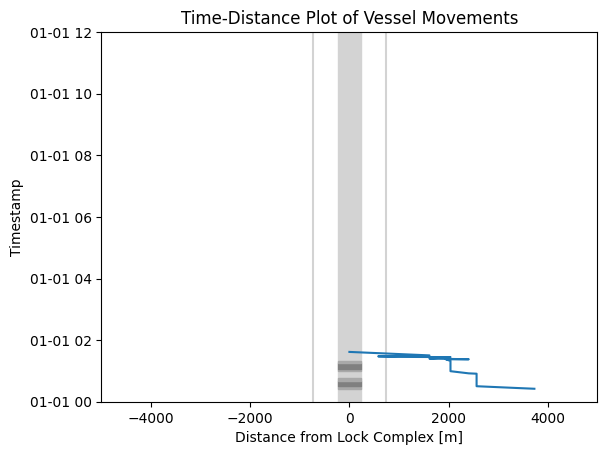

In [59]:
fig = lock_chamber_I.plot(xlimmin=-5000, xlimmax=5000, ylimmin=pd.Timestamp('2025-01-01'), ylimmax=pd.Timestamp('2025-01-01 12:00'))

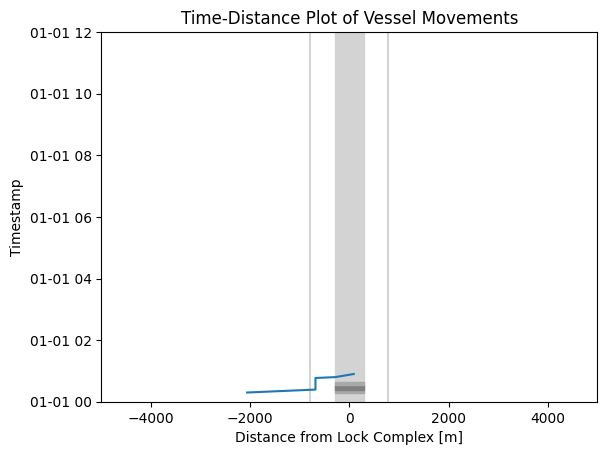

In [60]:
fig = lock_chamber_II.plot(xlimmin=-5000, xlimmax=5000, ylimmin=pd.Timestamp('2025-01-01'), ylimmax=pd.Timestamp('2025-01-01 12:00'))

In [61]:
lock_complex.vessel_planning

,id,node_from,node_to,direction,waiting_area,lineup_area,lock_chamber,L,B,T,...,time_arrival_at_approach_point,time_lock_operation_start,time_lock_entry_start,time_lock_entry_stop,time_lock_departure_start,time_lock_departure_stop,time_lock_operation_stop,time_potential_lock_gate_closure_start,time_to_traverse_waterway_without_lock,delay
0,b29ff196-1444-49f9-8adf-3efaaadea91f,waiting_end_1,waiting_start_1,0,Waiting area mid B,None,Lock_mid,400,20,5,...,2025-01-01 00:45:49.550491,2025-01-01 00:45:49.550491,2025-01-01 00:47:54.550491,2025-01-01 00:53:58.784604883,2025-01-01 01:13:58.784604883,2025-01-01 01:17:13.169054294,2025-01-01 01:19:18.169054294,2025-01-01 01:17:13.169054294,2025-01-01 00:29:03.380056,0 days 00:00:00
1,0218a68f-e282-4b25-98ce-e7169e1a09da,waiting_start_0,waiting_end_0,1,Waiting area west B,None,Lock_west,400,20,5,...,2025-01-01 00:53:10.734346,2025-01-01 00:53:10.734346,2025-01-01 00:55:15.734346,2025-01-01 00:52:59.721863395,2025-01-01 01:13:58.784604883,2025-01-01 01:23:41.937953118,2025-01-01 01:25:46.937953118,2025-01-01 01:23:41.937953118,2025-01-01 00:38:23.041291,0 days 00:00:00


In [62]:
lock_complex.operation_planning[lock_complex.operation_planning.lock_chamber == 'Lock_west']

,node_from,node_to,direction,lock_chamber,vessels,capacity_L,capacity_B,time_potential_lock_gate_opening_stop,time_lock_operation_start,time_lock_entry_start,...,time_gate_opening_stop,time_lock_departure_start,time_lock_departure_stop,time_lock_operation_stop,time_potential_lock_gate_closure_start,wlev_A,wlev_B,maximum_individual_delay,total_delay,status
lock_operation,,,,,,,,,,,,,,,,,,,,,
0,waiting_end_0,waiting_start_0,0,Lock_west,[],460.058268,40,2025-01-01 00:15:15.734346,2025-01-01 00:25:15.734346,2025-01-01 00:25:15.734346,...,2025-01-01 00:45:15.734346,2025-01-01 00:45:15.734346,2025-01-01 00:45:15.734346,2025-01-01 00:45:15.734346,2025-01-01 00:45:15.734346,None,None,NaN,NaN,NaN
1,waiting_start_0,waiting_end_0,1,Lock_west,[<__main__.Vessel object at 0x0000012F7AEC0FD0...,-339.941732,40,2025-01-01 00:37:54.550491,2025-01-01 00:45:49.550491,2025-01-01 00:47:54.550491,...,2025-01-01 01:13:58.784604883,2025-01-01 01:13:58.784604883,2025-01-01 01:23:41.937953118,2025-01-01 01:25:46.937953118,2025-01-01 01:23:41.937953118,None,None,NaN,NaN,NaN


In [63]:
lock_complex.operation_planning[lock_complex.operation_planning.lock_chamber == 'Lock_mid']

,node_from,node_to,direction,lock_chamber,vessels,capacity_L,capacity_B,time_potential_lock_gate_opening_stop,time_lock_operation_start,time_lock_entry_start,...,time_gate_opening_stop,time_lock_departure_start,time_lock_departure_stop,time_lock_operation_stop,time_potential_lock_gate_closure_start,wlev_A,wlev_B,maximum_individual_delay,total_delay,status
lock_operation,,,,,,,,,,,,,,,,,,,,,


In [64]:
df_eventtable = opentnsim.core.logutils.logbook2eventtable([*vessels, lock_chamber_II])
fig = generate_vessel_gantt_chart(df_eventtable)

In [65]:
df_eventtable = opentnsim.core.logutils.logbook2eventtable([*vessels ,lock_chamber_II])
fig = generate_vessel_gantt_chart(df_eventtable)

In [66]:
for vessel in vessels:
    df = pd.DataFrame(vessel.logbook)
    display(df)

,Message,Timestamp,Value,Geometry
0,Sailing from node NL_J1987 to node NL_J1988 start,2025-01-01 00:17:54.550491,0,POINT (3.82906439 51.31201982)
1,Sailing from node NL_J1987 to node NL_J1988 stop,2025-01-01 00:20:19.635288,580.339188,POINT (3.82613454 51.31689911)
2,Sailing from node NL_J1988 to node NL_J1749 start,2025-01-01 00:20:19.635288,580.339188,POINT (3.82613454 51.31689911)
3,Sailing from node NL_J1988 to node NL_J1749 stop,2025-01-01 00:21:20.660651,824.440639,POINT (3.82470089 51.31890076)
4,Sailing from node NL_J1749 to node waiting_end...,2025-01-01 00:21:20.660651,824.440639,POINT (3.82470089 51.31890076)
5,Sailing from node NL_J1749 to node waiting_end...,2025-01-01 00:23:39.109850,1378.237434,POINT (3.822259152006982 51.32363581593047)
6,Sailing from node waiting_end_1 to node waitin...,2025-01-01 00:23:39.109850,1378.237434,POINT (3.822259152006982 51.32363581593047)
7,Waiting for lock operation start,2025-01-01 00:23:39.109850,"{'origin': '', 'destination': '', 'route': [],...",POINT (3.822259152006982 51.32363581593047)
8,Waiting for lock operation stop,2025-01-01 00:46:15.294610,"{'origin': '', 'destination': '', 'route': [],...",POINT (3.822259152006982 51.32363581593047)
9,Sailing to first lock gate start,2025-01-01 00:46:15.294610,"{'origin': '', 'destination': '', 'route': [],...",POINT (3.822259152006982 51.32363581593047)


,Message,Timestamp,Value,Geometry
0,Sailing from node NL_J0446 to node NL_J0561 start,2025-01-01 00:14:44.354414,0,POINT (3.78477796 51.35404219)
1,Sailing from node NL_J0446 to node NL_J0561 stop,2025-01-01 00:23:59.663945,2221.238123,POINT (3.81361289 51.34578529)
2,Sailing from node NL_J0561 to node NL_J1992 start,2025-01-01 00:23:59.663945,2221.238123,POINT (3.81361289 51.34578529)
3,Sailing from node NL_J0561 to node NL_J1992 stop,2025-01-01 00:25:15.734346,2525.51973,POINT (3.81192199 51.34326373)
4,Sailing from node NL_J1992 to node NL_J1754 start,2025-01-01 00:25:15.734346,2525.51973,POINT (3.81192199 51.34326373)
5,Sailing from node NL_J1992 to node NL_J1754 start,2025-01-01 00:25:15.734346,2525.51973,POINT (3.81192199 51.34326373)
6,Sailing from node NL_J1992 to node NL_J1754 stop,2025-01-01 00:26:50.647668,2905.173016,POINT (3.81114055 51.33988738)
7,Sailing from node NL_J1754 to node waiting_sta...,2025-01-01 00:26:50.647668,2905.173016,POINT (3.81114055 51.33988738)
8,Sailing from node NL_J1754 to node waiting_sta...,2025-01-01 00:26:50.647668,3709.682464,POINT (3.81114055 51.33988738)
9,Sailing from node NL_J1754 to node waiting_sta...,2025-01-01 00:26:50.647668,3709.682464,POINT (3.81114055 51.33988738)


In [67]:
for i in range(len(vessels)): 
    print(vessels[i].route, "\n")

['NL_J1987', 'NL_J1988', 'NL_J1749', 'waiting_end_1', 'waiting_start_1', 'NL_J1754', 'NL_J1992', 'NL_J0561', 'NL_J0446'] 

['NL_J1992', 'NL_J1754', 'waiting_start_0', 'waiting_end_0', 'NL_J1749', 'NL_J1988', 'NL_J1987'] 



In [68]:
edge_data = env.graph.edges[lock_edges[0]]
lock_chamber = edge_data['Lock chamber'] # Get the first (and likely only) chamber object

In [69]:
lock_chamber
